In [3]:
!nvidia-smi

Thu Dec 15 12:21:53 2022       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 515.65.01    Driver Version: 515.65.01    CUDA Version: 11.7     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla T4            On   | 00000000:00:1E.0 Off |                    0 |
| N/A   42C    P8    16W /  70W |      2MiB / 15360MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

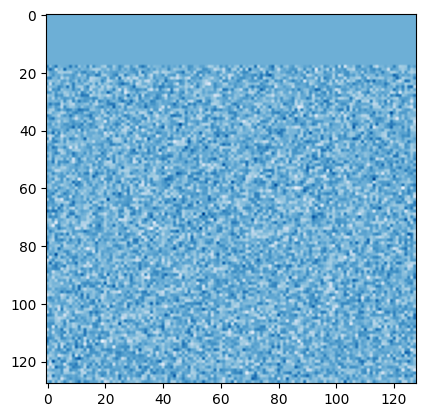

ValueError: Input and output must have the same number of spatial dimensions, but got input with spatial dimensions of [128] and output size of [10, 10]. Please provide input tensor in (N, C, d1, d2, ...,dK) format and output size in (o1, o2, ...,oK) format.

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision
x = torch.randn((128, 128))
x[:18,:] = torch.zeros_like(x[:18,:])
plt.imshow(x.numpy(), cmap="Blues")
plt.show()
y = torchvision.transforms.functional.resize(x.unsqueeze(0), (10, 10))

In [1]:
import torch
import gradio as gr
import importlib
import loaders
import functools
import edit
import importlib
from loaders import load_default
device = "mps"
vqgan = load_default(device)
vqgan.eval()

ModuleNotFoundError: No module named 'altair'

In [19]:
bp = functools.partial(edit.blend_paths, model, show=False)
lip_vector = torch.load("./latent_vectors/lipvector.pt")


In [20]:
# import torch
# torch.save(gender_vector, "./latent_vectors/gender.pt")

In [21]:
import torchvision
from transformers import CLIPProcessor, CLIPModel
class ProcessorGradientFlow():
    def __init__(self, device="cuda") -> None:
        self.device = device
        self.processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
        self.image_mean = [0.48145466, 0.4578275, 0.40821073]
        self.image_std = [0.26862954, 0.26130258, 0.27577711]
        self.normalize = torchvision.transforms.Normalize(
            self.image_mean,
            self.image_std
        )
        self.resize = torchvision.transforms.Resize(224)
        self.center_crop = torchvision.transforms.CenterCrop(224)
    def preprocess_img(self, images):
        images = self.center_crop(images)
        images = self.resize(images)
        images = self.center_crop(images)
        images = self.normalize(images)
        return images
    def __call__(self, images=[], **kwargs):
        processed_inputs = self.processor(**kwargs)
        processed_inputs["pixel_values"] = self.preprocess_img(images)
        processed_inputs = {key:value.to("cuda") for (key, value) in processed_inputs.items()}
        return processed_inputs

In [7]:
import torch.nn as nn
from img_processing import *
from utils import freeze_module
import matplotlib.pyplot as plt
from tqdm import tqdm
class ImagePromptOptimizer(nn.Module):
    def __init__(self, 
                vqgan, 
                clip,
                clip_preprocessor,
                iterations=100,
                lr = 0.01,
                save_vector=True,
                return_val="latent",
                make_grid=False) -> None:
        super().__init__()
        self.latent = None
        self.device = vqgan.device
        vqgan.eval()
        self.vqgan = vqgan
        self.clip = clip
        self.iterations = iterations
        self.lr = lr
        self.clip_preprocessor = clip_preprocessor
        self.make_grid = make_grid
    def set_latent(self, latent):
        self.latent = latent.detach()
    def set_params(self, lr, iterations):
        self.iterations = iterations
        self.lr = lr
    def forward(self, vector):
        base_latent = self.latent.detach().requires_grad_()
        trans_latent = base_latent + vector
        z_q, *_ = self.vqgan.quantize(trans_latent)
        dec = self.vqgan.decode(z_q)
        return dec
    def _get_clip_similarity(self, prompts, image, weights=None):
        if isinstance(prompts, str):
            prompts = [prompts]
        elif not isinstance(prompts, list):
            raise TypeError("Provide prompts as string or list of strings")
        clip_inputs = self.clip_preprocessor(text=prompts,
            images=image, return_tensors="pt", padding=True)
        clip_outputs = self.clip(**clip_inputs)
        similarity_logits = clip_outputs.logits_per_image
        if weights:
            similarity_logits *= weights
        return similarity_logits.sum()
    def get_similarity_loss(self, pos_prompts, neg_prompts, image):
        pos_logits = self._get_clip_similarity(pos_prompts, image)
        if neg_prompts:
            neg_logits = self._get_clip_similarity(neg_prompts, image)
        else:
            neg_logits = torch.tensor([0], device=self.device)
        loss = -torch.log(pos_logits) + torch.log(neg_logits)
        return loss
    def visualize(self, processed_img):
        if self.make_grid:
            self.index += 1
            plt.subplot(1, 9, self.index)
            plt.imshow(get_pil(processed_img[0]).detach().cpu())
        else:
            plt.imshow(get_pil(processed_img[0]).detach().cpu())
            plt.show()
    def optimize(self, latent, pos_prompts, neg_prompts):
        self.set_latent(latent)
        vector = torch.randn_like(self.latent, requires_grad=True)
        optim = torch.optim.Adam([vector], lr=0.01)
        if self.make_grid:
            plt.figure(figsize=(35, 25))
            self.index = 1
        for i in tqdm(range(self.iterations)):
            transformed_img = self(vector)
            processed_img = loop_post_process(transformed_img)
            loss = self.get_similarity_loss(pos_prompts, neg_prompts, processed_img)
            optim.zero_grad()
            loss.backward()
            optim.step()
            if i % self.iterations // 10 == 0: 
                self.visualize(processed_img)
        if self.make_grid:
            plt.savefig(f"plot {pos_prompts[0]}.png")
            plt.show()
        return vector if self.return_val == "vector" else self.latent + vector

In [23]:
processor = ProcessorGradientFlow()
clip = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
clip.to(device)

CLIPModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0): CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e-05, element

In [6]:
from img_processing import custom_to_pil
import edit
importlib.reload(edit)
from edit import blend_paths
class ImageState:
    def __init__(self, vqgan, prompt_optimizer: ImagePromptOptimizer) -> None:
        self.vqgan = vqgan
        self.device = vqgan.device
        #latentvectors
        self.lip_vector = torch.load("./latent_vectors/lipvector.pt")
        self.red_blue_vector = torch.load("./latent_vectors/red_blue.pt")
        self.green_purple_vector = torch.load("./latent_vectors/green_purple.pt")
        # self.gender_vector = torch.load("./latent_vectors/gender.pt")
        self.asian_vector = torch.load("./latent_vectors/asian10.pt", map_location="cpu")
        #latent transforms
        self.hair_rb = torch.zeros_like(self.lip_vector)
        self.lip_transforms = torch.zeros_like(self.lip_vector)
        self.gender_transforms = torch.zeros_like(self.lip_vector)
        self.prompt_transforms = torch.zeros_like(self.lip_vector) 
        self.hair_gp = torch.zeros_like(self.lip_vector)
        self.blend_latent = None
        self.quant = True
        self.prompt_optim = prompt_optimizer
    def _apply_vector(self, src, vector):
        new_latent = torch.lerp(src, src + vector, 1)
        return new_latent
    def _decode_latent(self, latent):
        current_im = self.vqgan.decode(latent.to(self.device))[0]
        return custom_to_pil(current_im)
    def _render_all_transformations(self):
        self.current_vector_transforms = [self.hair_rb, self.lip_transforms, self.hair_gp, self.gender_transforms, self.prompt_transforms]
        # new_latent = torch.lerp(self.blend_latent, self.blend_latent + sum(self.current_vector_transforms), 1)
        new_latent = self.blend_latent + sum(self.current_vector_transforms)
        if self.quant:
            new_latent, _, _ = self.vqgan.quantize(new_latent.to(self.device))
        return self._decode_latent(new_latent)
    def apply_gp_vector(self, weight):
        self.hair_gp = weight * self.green_purple_vector
        return self._render_all_transformations()
    def apply_rb_vector(self, weight):
        self.hair_rb = weight * self.red_blue_vector
        return self._render_all_transformations()
    def apply_lip_vector(self, weight):
        self.lip_transforms = weight * self.lip_vector
        return self._render_all_transformations()
    def update_requant(self, val):
        print(f"val = {val}")
        self.quant = val
        return self._render_all_transformations()
    def apply_gender_vector(self, weight):
        self.gender_transforms = weight * self.asian_vector
        return self._render_all_transformations()
    def blend(self, path1, path2, weight):
        img, latent = blend_paths(self.vqgan, path1, path2, weight=weight, show=False)
        self.blend_latent = latent
        return self._render_all_transformations()
    def apply_prompts(self, positive_prompts, negative_prompts, lr, iterations):
        self.prompt_optim.set_params(lr, iterations)
        transform = self.prompt_optim.optimize(self.blend_latent,
                                                positive_prompts,
                                                negative_prompts)
        self.prompt_transforms = transform
        return self._render_all_transformations()

NameError: name 'ImagePromptOptimizer' is not defined

In [25]:
test = ImageState(model)
test.blend("./test_data/face.jpeg", "./test_data/face2.jpeg", 0.5)
test.apply_lip_vector(0.6)

TypeError: __init__() missing 1 required positional argument: 'prompt_optimizer'

: 

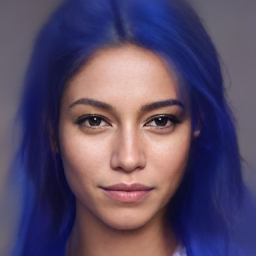

In [ ]:
test.apply_rb_vector(.8)

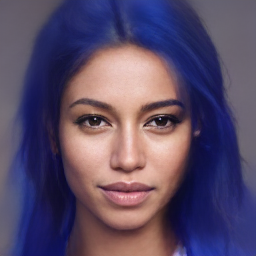

In [ ]:
test.apply_lip_vector(.6)

/opt/homebrew/Caskroom/miniforge/base/envs/taming/lib/python3.8/site-packages/torchvision/transforms/functional.py:442: UserWarning: Argument 'interpolation' of type int is deprecated since 0.13 and will be removed in 0.15. Please use InterpolationMode enum.
  warnings.warn(


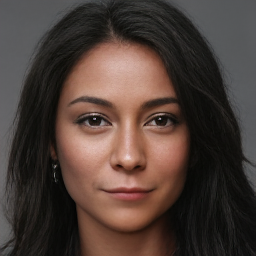

In [ ]:
test.blend("./test_data/face.jpeg", "./test_data/face2.jpeg", 0.1)

In [8]:
import functools
import edit
import importlib
importlib.reload(edit)
# bp = functools.partial(edit.blend_paths, model, show=False)
model = vqgan
promptoptim = ImagePromptOptimizer(model, clip, processor)
state = ImageState(model, promptoptim)
with gr.Blocks() as demo:
    with gr.Row():
        with gr.Column(scale=2):
            hair_red_blue = gr.Slider(
                label="hair red<->blue ",
                minimum=-.8,
                maximum=.8,
                value=0,
                step=0.1,
            )
            hair_green_purple = gr.Slider(
                label="hair green<->purple ",
                minimum=-.8,
                maximum=.8,
                value=0,
                step=0.1,
            )
            lip_size = gr.Slider(
                label="lip size",
                minimum=-1.9,
                value=0,
                maximum=1.9,
                step=0.1,
            )
            blend_weight = gr.Slider(
                label="0 is src image, 1 is blend_img",
                minimum=-0.,
                value=0,
                maximum=1.,
                step=0.1,
            )
            requantize = gr.Checkbox(
                label="requantize latents",
            )
            gender_weight = gr.Slider(
                label="gender weight (-1 female, 1 male)",
                minimum=-2.,
                value=0,
                maximum=2.,
                step=0.07,
            )
            with gr.Row():
                with gr.Column(scale=1):
                    base_img = gr.Image(label="base Image", type="filepath")
                    blend_img = gr.Image(label="image for face blending (optional)", type="filepath")
                with gr.Column(scale=2):
                    positive_prompts = gr.Textbox(label="Positive prompts")
                    negative_prompts = gr.Textbox(label="Negative prompts")
                    iterations = gr.Slider(minimum=10,
                                            maximum=300,
                                            value=100)
                    learning_rate = gr.Slider(minimum=1e-4,
                                            maximum=1,
                                            value=1e-2)
                    apply_prompts = gr.Button(value="Apply Prompts")

        with gr.Column(scale=1):
            out = gr.Image(interactive=False, shape=(200, 200))
            test = gr.Image(interactive=False, shape=(200, 200))
            i = gr.Button()
    gender_weight.change(state.apply_gender_vector, inputs=[gender_weight], outputs=out)
    requantize.change(state.update_requant, inputs=[requantize], outputs=out)
    lip_size.change(state.apply_lip_vector, inputs=[lip_size], outputs=out)
    hair_green_purple.change(state.apply_gp_vector, inputs=[hair_green_purple], outputs=out)
    hair_red_blue.change(state.apply_rb_vector, inputs=[hair_red_blue], outputs=out)
    blend_weight.change(state.blend, inputs=[base_img, blend_img, blend_weight], outputs=out)
    base_img.change(lambda x:x, inputs=base_img, outputs=out)
    blend_img.change(state.blend, inputs=[base_img, blend_img, blend_weight], outputs=out)
    apply_prompts.click(state.apply_prompts, inputs=[positive_prompts, negative_prompts, learning_rate, iterations], outputs=out)

demo.launch(inbrowser=True)

AttributeError: 'NoneType' object has no attribute 'device'